# EDA - Shopee Shops Data

Phân tích khám phá dữ liệu (Exploratory Data Analysis) cho dữ liệu shop trên Shopee.

**Dataset:** `shopee_data/shops.csv`

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

df = pd.read_csv('shopee_data/shops.csv')
print(f'Dataset: {df.shape[0]} shops, {df.shape[1]} columns')
df.head()

Dataset: 5638 shops, 10 columns


,shop_id,shop_name,location,rating_star,follower_count,is_official_shop,item_count,response_rate,response_time,crawled_at
0,962733632,Sthgruybfub.vn,NaN,4.784238,33775,False,9879,100,799,2026-03-07T21:51:00.837947
1,1008809970,Cà vạt chuyên dụng yzq007.vn,Nước ngoài,4.833333,1879,False,96,100,6497,2026-03-07T21:51:13.492509
2,322530470,ewann.vn,Nước ngoài,4.904741,11968,True,4429,97,6513,2026-03-07T21:51:26.016777
3,183199642,Binstore thời trang nam,Hà Tĩnh,4.829123,12683,False,142,91,2361,2026-03-07T21:51:38.013949
4,308456542,cheesenhujm.vn,NaN,4.666000,14692,False,3412,100,767,2026-03-07T21:51:50.661447


## 1. Tổng quan dữ liệu

In [36]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
print(missing_df[missing_df['count'] > 0])
print(f'\nTotal rows with any missing: {df.isnull().any(axis=1).sum()} / {len(df)}')

=== Data Types ===
shop_id               int64
shop_name            object
location             object
rating_star         float64
follower_count        int64
is_official_shop       bool
item_count            int64
response_rate         int64
response_time         int64
crawled_at           object
dtype: object

=== Missing Values ===
          count  percent
location   1668     29.6

Total rows with any missing: 1668 / 5638


In [37]:
print('=== Descriptive Statistics (Numeric) ===')
df.describe().round(2)

=== Descriptive Statistics (Numeric) ===


,shop_id,rating_star,follower_count,item_count,response_rate,response_time
count,5.638000e+03,5638.00,5638.00,5638.00,5638.00,5638.00
mean,4.857098e+08,4.81,62820.36,555.61,78.52,7359.53
std,4.275241e+08,0.15,173877.23,6859.56,28.45,5704.45
min,2.963800e+04,0.00,1.00,0.00,0.00,0.00
25%,1.007013e+08,4.77,3242.50,43.00,70.25,3438.25
50%,3.581381e+08,4.85,14714.00,110.00,91.00,6738.50
75%,8.148517e+08,4.89,55752.25,295.00,99.00,10388.50
max,1.686490e+09,5.00,5457422.00,421653.00,100.00,80412.00


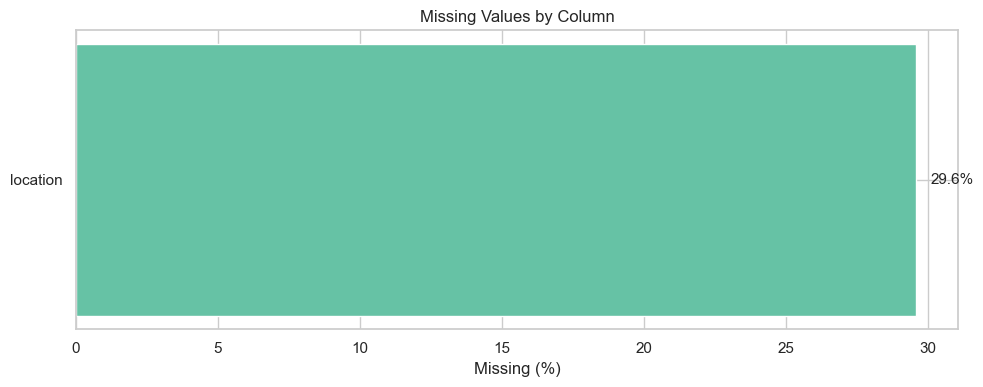

In [38]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))
missing_cols = missing_df[missing_df['count'] > 0].sort_values('count', ascending=True)
if not missing_cols.empty:
    bars = ax.barh(missing_cols.index, missing_cols['percent'])
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column')
    for bar, pct in zip(bars, missing_cols['percent']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{pct}%', va='center')
else:
    ax.text(0.5, 0.5, 'No missing values!', transform=ax.transAxes, ha='center', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Phân bố Rating Star

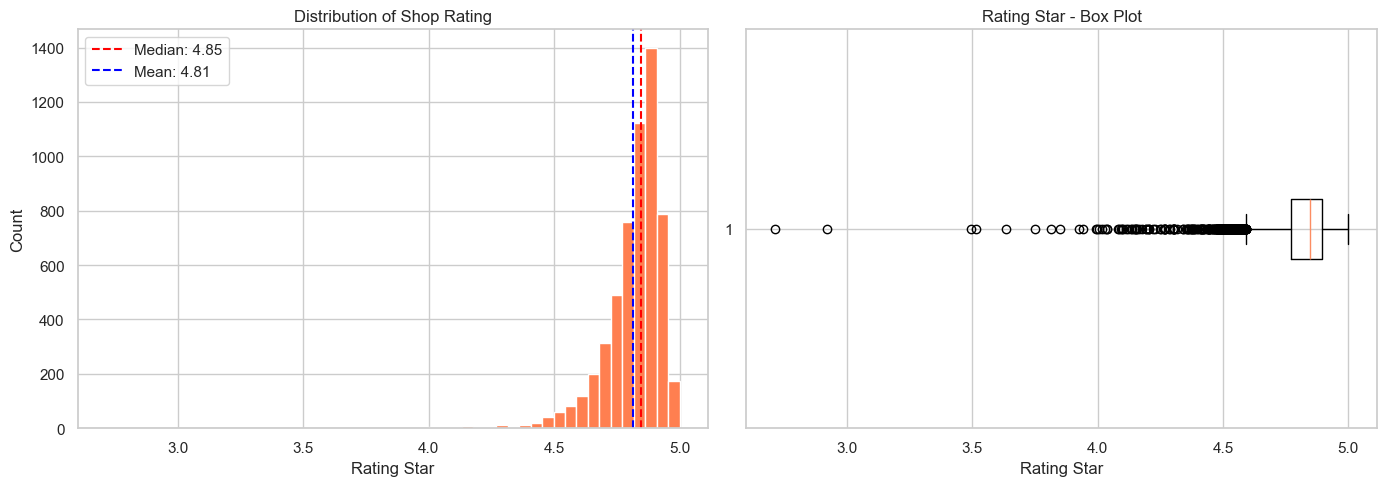

Shops with no rating (=0): 1
Rated shops: 5637
Rating range: 2.71 - 5.00


In [39]:
# Filter out shops with no rating (rating_star == 0 likely means no data)
rated = df[df['rating_star'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(rated['rating_star'], bins=50, edgecolor='white', color='coral')
axes[0].axvline(rated['rating_star'].median(), color='red', linestyle='--', label=f'Median: {rated["rating_star"].median():.2f}')
axes[0].axvline(rated['rating_star'].mean(), color='blue', linestyle='--', label=f'Mean: {rated["rating_star"].mean():.2f}')
axes[0].set_xlabel('Rating Star')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Shop Rating')
axes[0].legend()

# Box plot
axes[1].boxplot(rated['rating_star'], vert=False)
axes[1].set_xlabel('Rating Star')
axes[1].set_title('Rating Star - Box Plot')

plt.tight_layout()
plt.show()

print(f'Shops with no rating (=0): {(df["rating_star"] == 0).sum()}')
print(f'Rated shops: {len(rated)}')
print(f'Rating range: {rated["rating_star"].min():.2f} - {rated["rating_star"].max():.2f}')

## 3. Phân bố Follower Count

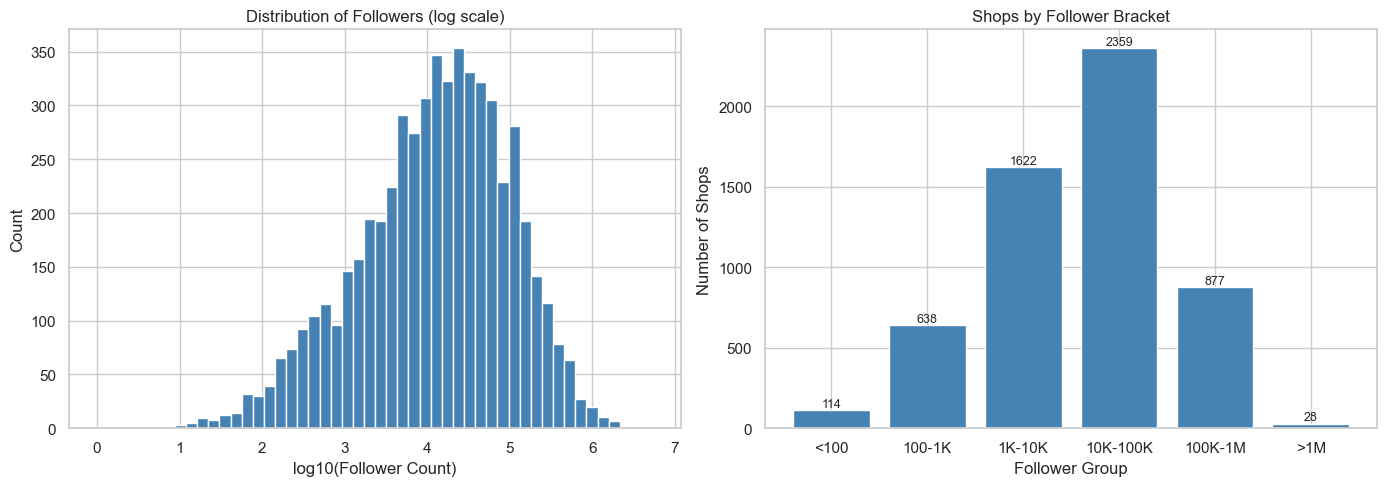

Median followers: 14,714
Mean followers: 62,820
Top 5 shops by followers:


,shop_name,follower_count,rating_star,is_official_shop
37,Topick Global,5457422,4.736347,False
3408,LOVITO OFFICIAL STORE,4523198,4.812610,True
3531,Xiaozhainv.vn——Fashion woman,3680598,4.843600,True
4492,Peonyb.store,2033430,4.811738,False
848,Coolmate - Official Store,1895254,4.924511,True


In [40]:
active = df[df['follower_count'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log scale histogram
axes[0].hist(np.log10(active['follower_count']), bins=50, edgecolor='white', color='steelblue')
axes[0].set_xlabel('log10(Follower Count)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Followers (log scale)')

# Follower brackets
bins = [0, 100, 1000, 10000, 100000, 1000000, float('inf')]
labels = ['<100', '100-1K', '1K-10K', '10K-100K', '100K-1M', '>1M']
active_copy = active.copy()
active_copy['follower_group'] = pd.cut(active_copy['follower_count'], bins=bins, labels=labels)
group_counts = active_copy['follower_group'].value_counts().reindex(labels)
bars = axes[1].bar(group_counts.index, group_counts.values, color='steelblue', edgecolor='white')
for bar, val in zip(bars, group_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val), ha='center', fontsize=9)
axes[1].set_xlabel('Follower Group')
axes[1].set_ylabel('Number of Shops')
axes[1].set_title('Shops by Follower Bracket')

plt.tight_layout()
plt.show()

print(f'Median followers: {active["follower_count"].median():,.0f}')
print(f'Mean followers: {active["follower_count"].mean():,.0f}')
print(f'Top 5 shops by followers:')
df.nlargest(5, 'follower_count')[['shop_name', 'follower_count', 'rating_star', 'is_official_shop']]

## 4. Phân bố Item Count (Số lượng sản phẩm)

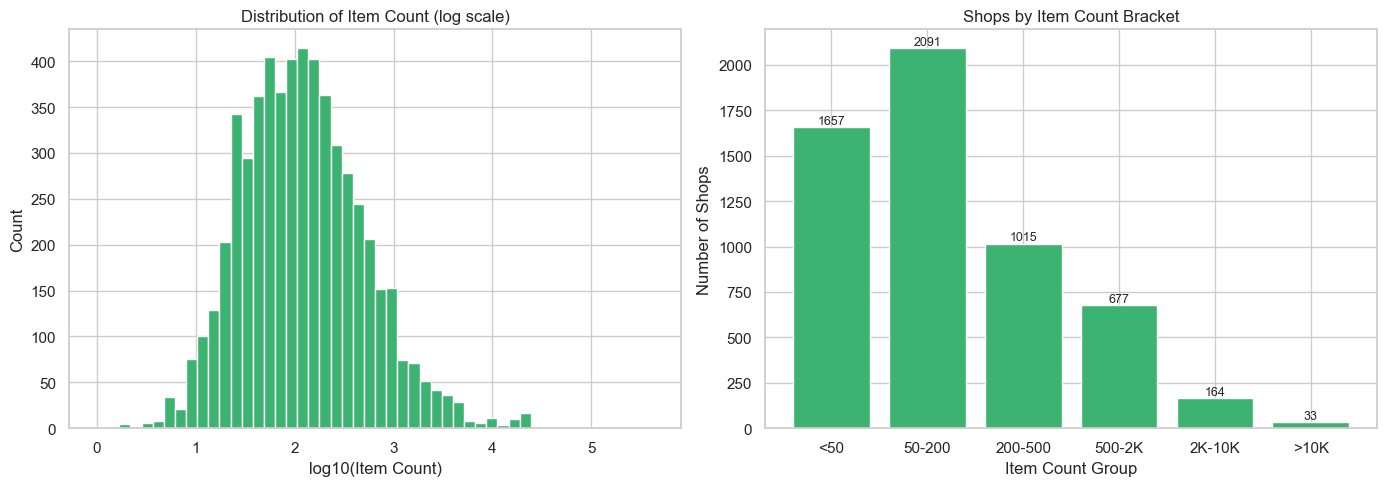

Median items: 110
Mean items: 556


In [41]:
has_items = df[df['item_count'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log scale histogram
axes[0].hist(np.log10(has_items['item_count']), bins=50, edgecolor='white', color='mediumseagreen')
axes[0].set_xlabel('log10(Item Count)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Item Count (log scale)')

# Item brackets
bins_item = [0, 50, 200, 500, 2000, 10000, float('inf')]
labels_item = ['<50', '50-200', '200-500', '500-2K', '2K-10K', '>10K']
has_items_copy = has_items.copy()
has_items_copy['item_group'] = pd.cut(has_items_copy['item_count'], bins=bins_item, labels=labels_item)
group_counts = has_items_copy['item_group'].value_counts().reindex(labels_item)
bars = axes[1].bar(group_counts.index, group_counts.values, color='mediumseagreen', edgecolor='white')
for bar, val in zip(bars, group_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val), ha='center', fontsize=9)
axes[1].set_xlabel('Item Count Group')
axes[1].set_ylabel('Number of Shops')
axes[1].set_title('Shops by Item Count Bracket')

plt.tight_layout()
plt.show()

print(f'Median items: {has_items["item_count"].median():,.0f}')
print(f'Mean items: {has_items["item_count"].mean():,.0f}')

## 5. Phân tích Location (Địa điểm shop)

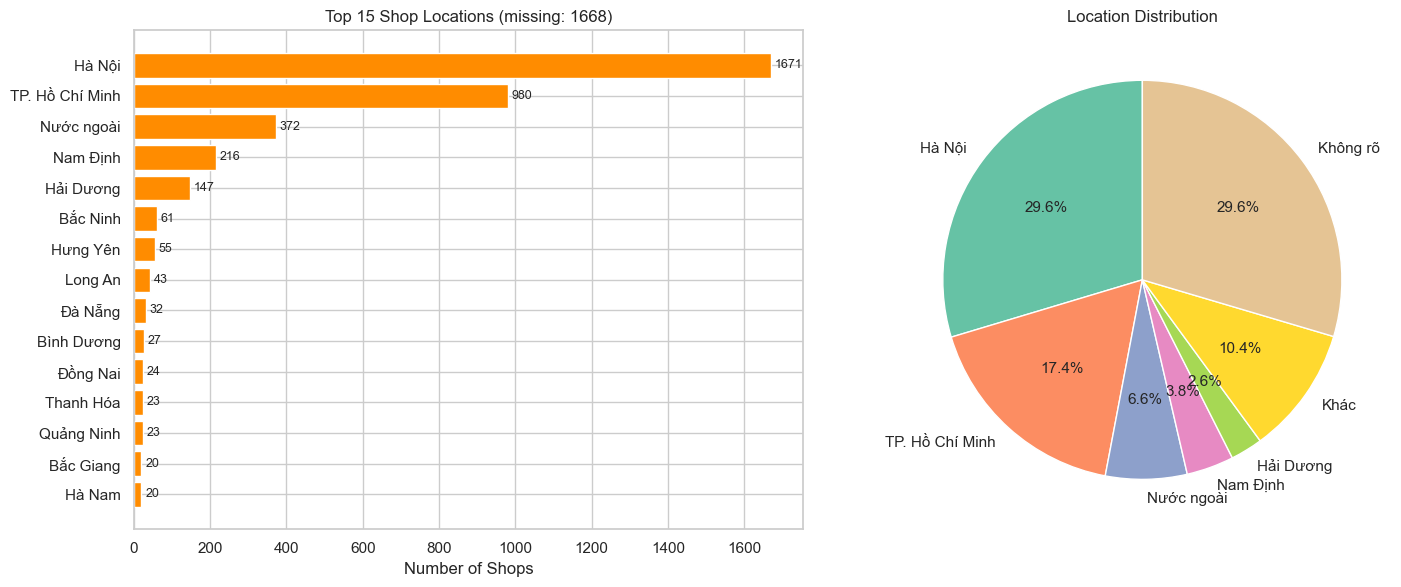

Total unique locations: 58
Missing location: 1668 (29.6%)


In [42]:
location_counts = df['location'].value_counts()
missing_loc = df['location'].isnull().sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 15 locations
top_locs = location_counts.head(15)
bars = axes[0].barh(top_locs.index[::-1], top_locs.values[::-1], color='darkorange', edgecolor='white')
for bar, val in zip(bars, top_locs.values[::-1]):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
axes[0].set_xlabel('Number of Shops')
axes[0].set_title(f'Top 15 Shop Locations (missing: {missing_loc})')

# Pie chart top 5 + Others
top5 = location_counts.head(5)
others = location_counts.iloc[5:].sum()
pie_data = pd.concat([top5, pd.Series({'Khác': others, 'Không rõ': missing_loc})])
axes[1].pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Location Distribution')

plt.tight_layout()
plt.show()

print(f'Total unique locations: {df["location"].nunique()}')
print(f'Missing location: {missing_loc} ({missing_loc/len(df)*100:.1f}%)')

## 6. Official Shop vs Normal Shop

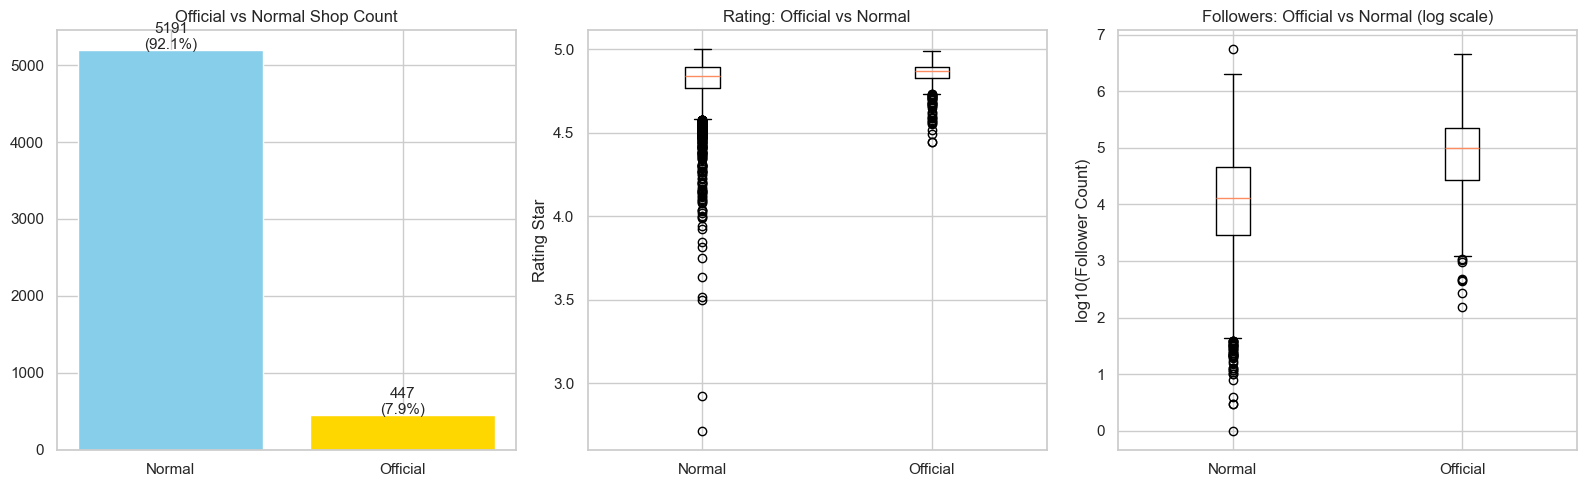

,count,avg_rating,median_followers,avg_items,avg_response_rate
is_official_shop,,,,,
False,5191,4.81,12915.0,453.62,77.05
True,447,4.85,98018.0,1740.01,95.62


In [43]:
official = df[df['is_official_shop'] == True]
normal = df[df['is_official_shop'] == False]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Count
counts = df['is_official_shop'].value_counts()
axes[0].bar(['Normal', 'Official'], [counts.get(False, 0), counts.get(True, 0)], 
            color=['skyblue', 'gold'], edgecolor='white')
for i, v in enumerate([counts.get(False, 0), counts.get(True, 0)]):
    axes[0].text(i, v + 20, f'{v}\n({v/len(df)*100:.1f}%)', ha='center')
axes[0].set_title('Official vs Normal Shop Count')

# Rating comparison
rated_data = df[df['rating_star'] > 0]
axes[1].boxplot(
    [rated_data[rated_data['is_official_shop']==False]['rating_star'],
     rated_data[rated_data['is_official_shop']==True]['rating_star']],
    labels=['Normal', 'Official']
)
axes[1].set_ylabel('Rating Star')
axes[1].set_title('Rating: Official vs Normal')

# Follower comparison
axes[2].boxplot(
    [normal[normal['follower_count']>0]['follower_count'].apply(np.log10),
     official[official['follower_count']>0]['follower_count'].apply(np.log10)],
    labels=['Normal', 'Official']
)
axes[2].set_ylabel('log10(Follower Count)')
axes[2].set_title('Followers: Official vs Normal (log scale)')

plt.tight_layout()
plt.show()

# Summary table
summary = df.groupby('is_official_shop').agg(
    count=('shop_id', 'count'),
    avg_rating=('rating_star', 'mean'),
    median_followers=('follower_count', 'median'),
    avg_items=('item_count', 'mean'),
    avg_response_rate=('response_rate', 'mean')
).round(2)
summary

## 7. Response Rate & Response Time

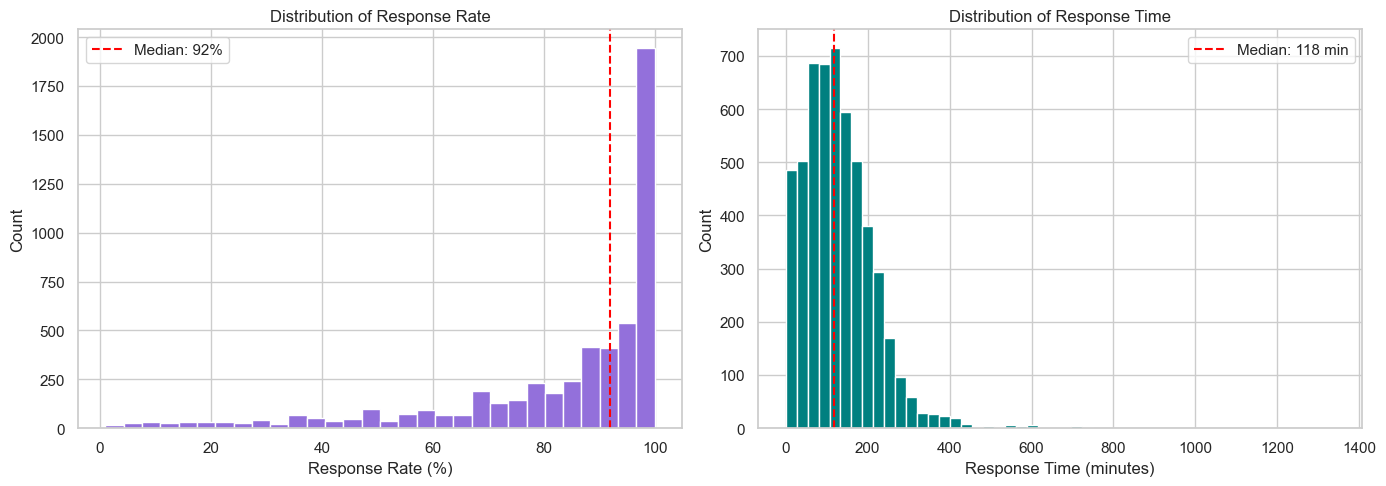

Shops with no response data: 305
Response rate >= 90%: 3004 (56.3%)
Median response time: 118 minutes


In [44]:
has_response = df[df['response_rate'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Response rate distribution
axes[0].hist(has_response['response_rate'], bins=30, edgecolor='white', color='mediumpurple')
axes[0].set_xlabel('Response Rate (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Response Rate')
axes[0].axvline(has_response['response_rate'].median(), color='red', linestyle='--', label=f'Median: {has_response["response_rate"].median():.0f}%')
axes[0].legend()

# Response time (convert seconds to minutes)
has_time = df[(df['response_time'] > 0) & (df['response_time'] < 86400)]  # < 24h
response_mins = has_time['response_time'] / 60
axes[1].hist(response_mins, bins=50, edgecolor='white', color='teal')
axes[1].set_xlabel('Response Time (minutes)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Response Time')
axes[1].axvline(response_mins.median(), color='red', linestyle='--', label=f'Median: {response_mins.median():.0f} min')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Shops with no response data: {(df["response_rate"] == 0).sum()}')
print(f'Response rate >= 90%: {(has_response["response_rate"] >= 90).sum()} ({(has_response["response_rate"] >= 90).sum()/len(has_response)*100:.1f}%)')
print(f'Median response time: {response_mins.median():.0f} minutes')

## 8. Correlation Analysis

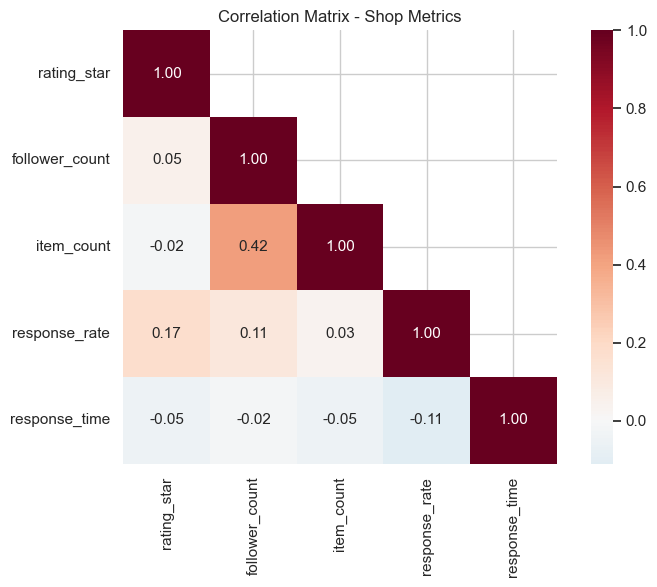

In [45]:
numeric_cols = ['rating_star', 'follower_count', 'item_count', 'response_rate', 'response_time']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, mask=mask, ax=ax, square=True)
ax.set_title('Correlation Matrix - Shop Metrics')
plt.tight_layout()
plt.show()

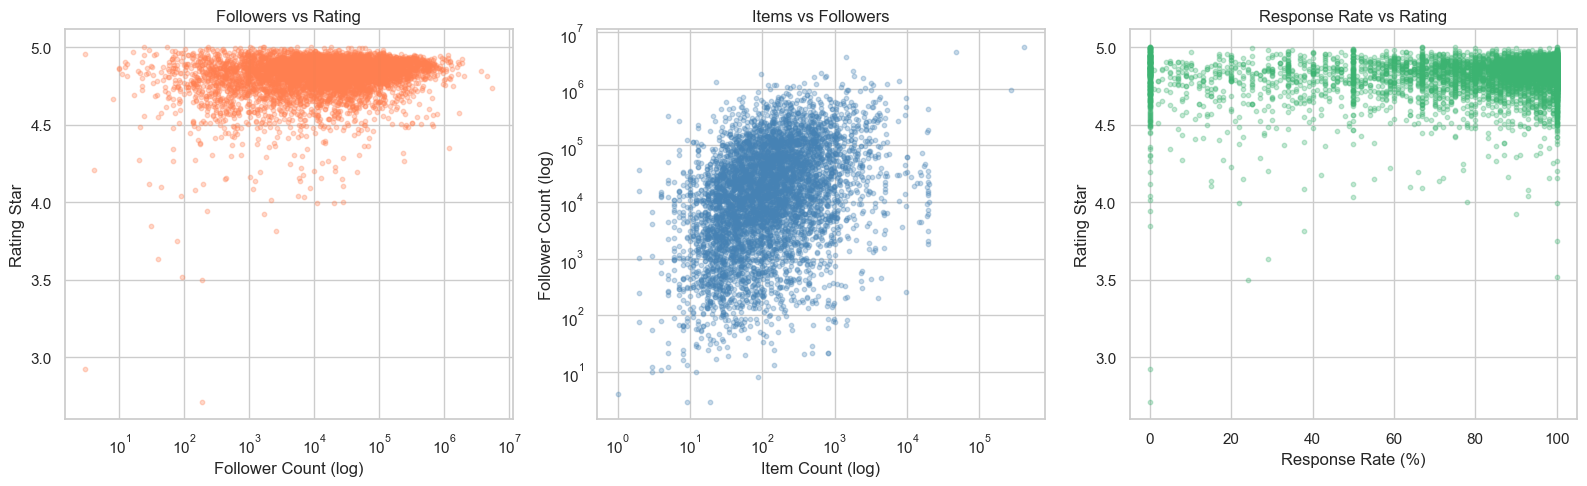

In [46]:
# Scatter plots of key relationships
active_df = df[(df['rating_star'] > 0) & (df['follower_count'] > 0) & (df['item_count'] > 0)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(active_df['follower_count'], active_df['rating_star'], alpha=0.3, s=10, color='coral')
axes[0].set_xscale('log')
axes[0].set_xlabel('Follower Count (log)')
axes[0].set_ylabel('Rating Star')
axes[0].set_title('Followers vs Rating')

axes[1].scatter(active_df['item_count'], active_df['follower_count'], alpha=0.3, s=10, color='steelblue')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Item Count (log)')
axes[1].set_ylabel('Follower Count (log)')
axes[1].set_title('Items vs Followers')

axes[2].scatter(active_df['response_rate'], active_df['rating_star'], alpha=0.3, s=10, color='mediumseagreen')
axes[2].set_xlabel('Response Rate (%)')
axes[2].set_ylabel('Rating Star')
axes[2].set_title('Response Rate vs Rating')

plt.tight_layout()
plt.show()

## 9. Top Shops Analysis

In [47]:
print('=== Top 10 by Followers ===')
display(df.nlargest(10, 'follower_count')[['shop_name', 'location', 'follower_count', 'rating_star', 'item_count', 'is_official_shop']])

print('\n=== Top 10 by Item Count ===')
display(df.nlargest(10, 'item_count')[['shop_name', 'location', 'item_count', 'follower_count', 'rating_star', 'is_official_shop']])

print('\n=== Top 10 by Rating (min 1000 followers) ===')
qualified = df[df['follower_count'] >= 1000]
display(qualified.nlargest(10, 'rating_star')[['shop_name', 'location', 'rating_star', 'follower_count', 'item_count', 'is_official_shop']])

=== Top 10 by Followers ===


,shop_name,location,follower_count,rating_star,item_count,is_official_shop
37,Topick Global,Nước ngoài,5457422,4.736347,421653,False
3408,LOVITO OFFICIAL STORE,Nước ngoài,4523198,4.812610,47015,True
3531,Xiaozhainv.vn——Fashion woman,NaN,3680598,4.843600,1454,True
4492,Peonyb.store,NaN,2033430,4.811738,1824,False
848,Coolmate - Official Store,Bắc Ninh,1895254,4.924511,651,True
1270,Teelab Official,Hà Nội,1861611,4.899458,96,True
3220,CAMA STORE,Thanh Hóa,1705518,4.572630,753,False
1878,TLEE JEWELRY Official Store,NaN,1694484,4.889805,1831,True
2204,YODY Official Store,NaN,1637250,4.906675,522,True
3444,CƯỜNG DUNG - CHUYÊN SỈ LẺ 2,NaN,1635305,4.823694,743,False



=== Top 10 by Item Count ===


,shop_name,location,item_count,follower_count,rating_star,is_official_shop
37,Topick Global,Nước ngoài,421653,5457422,4.736347,False
363,Topick Fashion,Nước ngoài,270658,966672,4.762336,False
3408,LOVITO OFFICIAL STORE,Nước ngoài,47015,4523198,4.812610,True
2330,COFORDOS,Nước ngoài,19991,10213,4.774810,True
567,HEALMEYOU,Nước ngoài,19925,21263,4.758657,True
431,QUTZZMND MALL,Nước ngoài,19840,6172,4.725772,True
4091,Gutgojo Mall,Nước ngoài,19827,13205,4.799037,True
23,Stationwa,Nước ngoài,19824,1827,4.768430,True
4098,UUMIR Official Store,Nước ngoài,19747,437384,4.797339,True
4960,PETOFQQ MALL,Nước ngoài,19724,7115,4.742827,True



=== Top 10 by Rating (min 1000 followers) ===


,shop_name,location,rating_star,follower_count,item_count,is_official_shop
2767,DEZI Store,Hà Nội,5.000000,1612,71,False
4182,Ellie _Váy cưới Cao Cấp Ellie,Nam Định,5.000000,8918,100,False
4216,VÁY CƯỚI CAO CẤP EVA,Nam Định,5.000000,1683,28,False
5153,Thời Trang Cao Cấp DYNLIN,Hà Nội,5.000000,1017,100,False
4209,SAM LUXURY BRIDAL,Nam Định,4.999605,18202,29,False
4224,Váy cưới cao cấp RoseLisa,Nam Định,4.998964,5369,28,False
1882,Trang Sức 3T,Bình Thuận,4.997396,60161,74,False
4163,Tiệm Váy Cưới,Nam Định,4.996904,14010,260,False
1884,3H Jewelry,NaN,4.995988,54451,293,False
2634,QuynhQueen,Hải Dương,4.993662,33394,8,False


## 10. Location Deep Dive

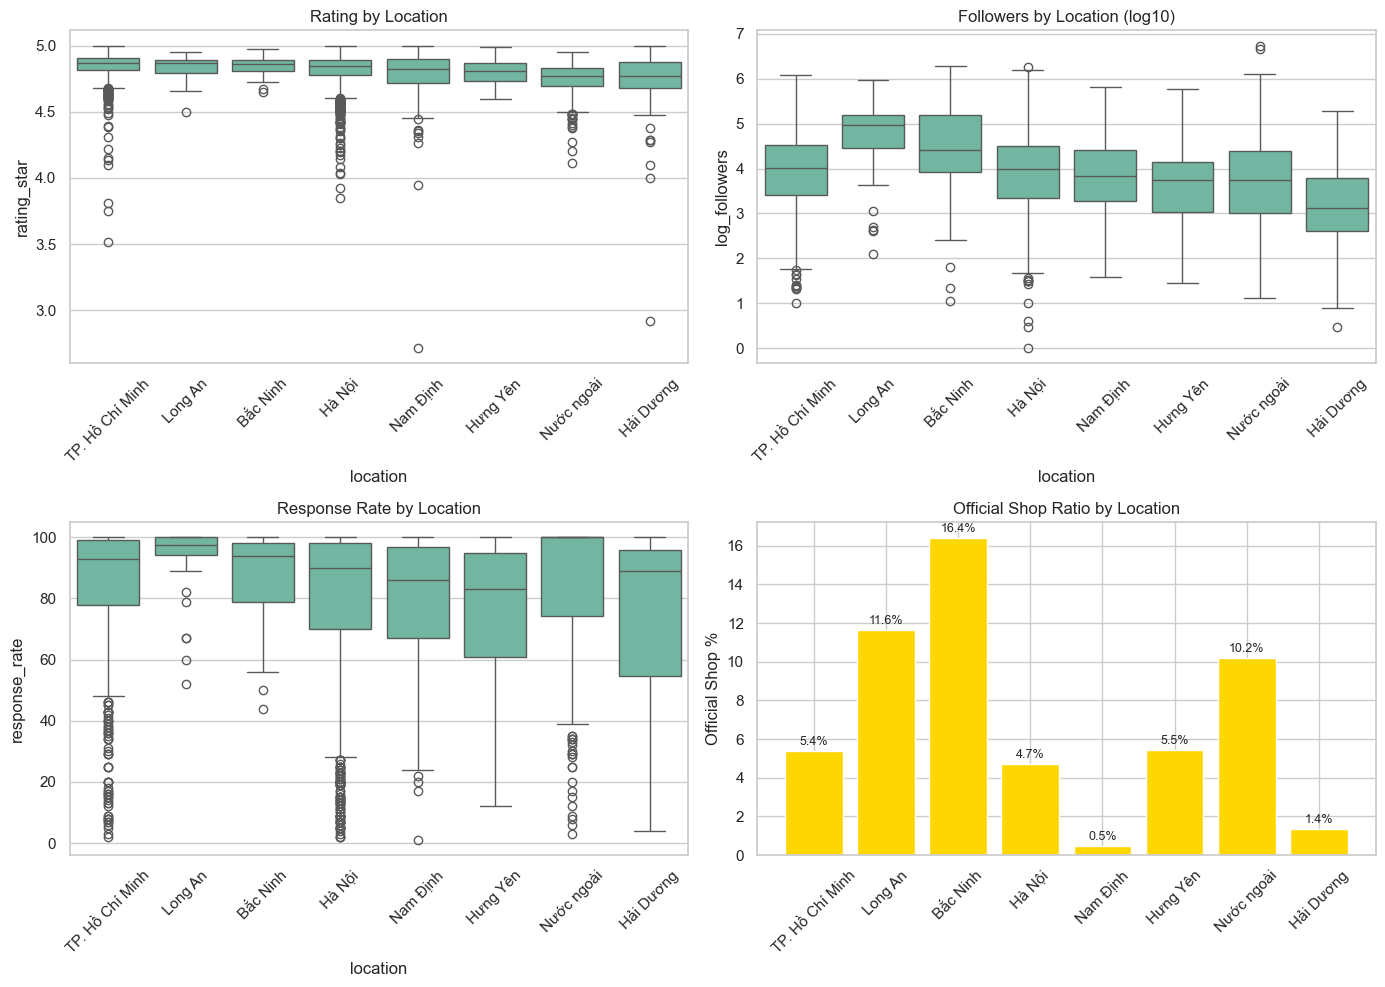

In [48]:
# Compare metrics by top locations
top_locations = df['location'].value_counts().head(8).index.tolist()
loc_df = df[df['location'].isin(top_locations)].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rating by location
loc_rated = loc_df[loc_df['rating_star'] > 0]
order = loc_rated.groupby('location')['rating_star'].median().sort_values(ascending=False).index
sns.boxplot(data=loc_rated, x='location', y='rating_star', order=order, ax=axes[0, 0])
axes[0, 0].set_title('Rating by Location')
axes[0, 0].tick_params(axis='x', rotation=45)

# Followers by location
loc_active = loc_df[loc_df['follower_count'] > 0].copy()
loc_active['log_followers'] = np.log10(loc_active['follower_count'])
sns.boxplot(data=loc_active, x='location', y='log_followers', order=order, ax=axes[0, 1])
axes[0, 1].set_title('Followers by Location (log10)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Response rate by location
loc_resp = loc_df[loc_df['response_rate'] > 0]
sns.boxplot(data=loc_resp, x='location', y='response_rate', order=order, ax=axes[1, 0])
axes[1, 0].set_title('Response Rate by Location')
axes[1, 0].tick_params(axis='x', rotation=45)

# Official shop ratio by location
official_ratio = loc_df.groupby('location')['is_official_shop'].mean().reindex(order) * 100
axes[1, 1].bar(official_ratio.index, official_ratio.values, color='gold', edgecolor='white')
axes[1, 1].set_ylabel('Official Shop %')
axes[1, 1].set_title('Official Shop Ratio by Location')
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(official_ratio.values):
    axes[1, 1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 11. Data Quality Summary

In [49]:
print('=== Data Quality Report ===')
print(f'Total shops: {len(df)}')
print(f'Unique shops: {df["shop_id"].nunique()}')
print(f'Duplicated shop_id: {df.duplicated(subset=["shop_id"]).sum()}')
print()

# Potential issues
issues = {
    'Missing shop_name': df['shop_name'].isnull().sum(),
    'Missing location': df['location'].isnull().sum(),
    'Rating = 0 (no data)': (df['rating_star'] == 0).sum(),
    'Follower = 0': (df['follower_count'] == 0).sum(),
    'Item count = 0': (df['item_count'] == 0).sum(),
    'Response rate = 0': (df['response_rate'] == 0).sum(),
    'Response time = 0': (df['response_time'] == 0).sum(),
}

issues_df = pd.DataFrame([
    {'Issue': k, 'Count': v, 'Percent': f'{v/len(df)*100:.1f}%'} for k, v in issues.items()
])
display(issues_df)

# Shops with all zero metrics (likely failed crawl)
failed = df[(df['rating_star'] == 0) & (df['follower_count'] == 0) & (df['item_count'] == 0)]
print(f'\nLikely failed crawl (all zeros): {len(failed)} shops ({len(failed)/len(df)*100:.1f}%)')

=== Data Quality Report ===
Total shops: 5638
Unique shops: 5638
Duplicated shop_id: 0



,Issue,Count,Percent
0,Missing shop_name,0,0.0%
1,Missing location,1668,29.6%
2,Rating = 0 (no data),1,0.0%
3,Follower = 0,0,0.0%
4,Item count = 0,1,0.0%
5,Response rate = 0,305,5.4%
6,Response time = 0,324,5.7%



Likely failed crawl (all zeros): 0 shops (0.0%)
